# MAGI v0.8.3 — fixing the energy↔geometry coupling

v0.8.2 reproduced every **marginal** of the CR crossing population correctly and
still lost ~15 % of the detector rate. The cause was measured in
`S1GDMLSRON_CryoSphereEmission/docs/MAGI_validation_note.md` §4b:

| v0.8.2 CR, marginals | MAGI / training |
|---|---|
| energy decades 0.1 MeV → 10 GeV | 0.970 – 1.013 |
| muon fraction | **1.000** |
| fraction of rays intersecting the Detector-1 box | 1.027 |

All correct. But binned by impact parameter `b` to Detector 1 — how nearly a
crossing points at the absorber:

| cut | median E train | median E MAGI | ratio |
|---|---|---|---|
| all ingoing | 12.51 | 10.20 | 0.816 |
| b < 10 mm | 13.29 | 6.22 | 0.468 |
| b < 1 mm | 9.88 | 2.22 | **0.225** |

The truth is **flat in `b`** — energy and aiming are independent. v0.8.2 invented
an anti-correlation, so the particles it aimed at the detector were far too
soft. Right count, right muon fraction, wrong energy.

## The three changes

1. **`energy_condition_geometry=True`** — factorize the joint as
   `p(geometry|z) · p(energy|geometry,z)` instead of making the latent carry the
   coupling alone. The four geometry targets are concatenated onto the energy
   branch input: the **true** ones at train time (teacher forcing), the
   **sampled** ones at generation. The geometry heads never see them, so
   nothing leaks into their own reconstruction.
2. **`latent_dim` 8 → 12** — the failure is a bottleneck symptom: fitting both
   marginals while distorting the joint is what a too-narrow shared code does.
3. **`magi.energy_vs_impact_parameter`** — the validation metric that would have
   caught this. Marginal-only validation cannot see a joint error.

Everything else is v0.8.2: RQS-flow continuum with CDF pre-warp, pinned 4 eV
lines, focal gate supervision, learnable coupling prior with zone conditioning.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import json, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
tf.config.set_visible_devices([], "GPU")

import magi
magi.initialize_environment(seed=42, cpu_only=True)
magi.set_plot_theme("light")
print("magi", magi.__version__, "|", magi.__file__)
print("energy_vs_impact_parameter available:",
      hasattr(magi, "energy_vs_impact_parameter"))

magi 0.8.2 | /Volumes/X10Pro/MAGI/MAGI_package/magi/__init__.py
energy_vs_impact_parameter available: True


## 1. Data — CR, the source that exhibits the defect

Same SRON CryoSphere as v0.8.2: centre (0, 0, −507.66), R = 100 mm.

In [2]:
SOURCE = "CR"
TRAINING_DATA_DIR = "/Volumes/X10Pro/MAGI/TrainingData"
SOURCE_FILE = f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereCR.dat"

center = (0.0, 0.0, -507.66)
R = 100.0
X_IFU_RESOLUTION_EV = 4.0
FWHM_MEV = X_IFU_RESOLUTION_EV * 1e-6

# Detector 1 centre, from the GDML and confirmed against the hit extent
# (x span 2.0 mm, y span 0.0023 mm, z span 2.0 mm)
DET1 = np.array([-0.1, -0.25, -471.54])

df = magi.load_detector_table(filepath=SOURCE_FILE, sep=r"\s+")
magi.report_basic_table_checks(df)

prep = magi.build_physical_features(df, center=center, radius=R)
magi.print_physical_summary(prep)

feat_base = prep["features"]
E_all = feat_base["Energy"].to_numpy()
print(f"\n{SOURCE}: {len(df):,} rows, {E_all.size:,} valid energies")

N rows: 3443885
  ParticleName      Energy        X        Y        Z        Vx        Vy  \
0        gamma    0.367431  53.2306 -72.7807 -548.471  0.201221  0.958547   
1          mu-  716.273000 -25.0220  88.2329 -544.881  0.705749 -0.707037   
2        gamma    0.739842  53.3597  58.3337 -448.010 -0.280581  0.182790   
3    anti_nu_e   23.225500  46.3443  10.0797 -420.700 -0.093070  0.222552   
4        gamma    0.263092  64.1741 -67.0382 -542.076 -0.997532 -0.061041   

         Vz  
0 -0.201739  
1 -0.044910  
2 -0.942264  
3 -0.970468  
4 -0.034698  



NaN per column:
 ParticleName    0
Energy          0
X               0
Y               0
Z               0
Vx              0
Vy              0
Vz              0
dtype: int64



--- RAW sphere check ---
r: mean = 99.12126741081232 std = 0.2926107376125263 min = 98.93974421814974 max = 100.0601790229645
Mean absolute deviation from R: 0.8798800962455824

--- RAW direction norm check ---
||v||: mean = 1.000000000151691 std = 2.886050517567763e-07 min = 0.9999991541486423 max = 1.000000833076153


Mean absolute deviation from 1: 2.400484751714334e-07

--- PROJECTED sphere check ---
r_proj: mean = 99.99999999999946 std = 4.618982489423185e-13 min = 99.99999999999896 max = 99.99999999999903
Mean absolute deviation from R: 1.0017854383603663e-12

--- RENORMALIZED direction check ---
||vhat||: mean = 0.9999999999989932 std = 6.6974366758165815e-15 min = 0.9999999999989996 max = 0.9999999999990002


Mean absolute deviation from 1: 1.000053489442588e-12

--- Energy check ---
E: min = 0.00039337 max = 583511.0 #E<=0 = 0

--- u_r check ---
u_r: min = -0.999999 max = 0.999999 mean = 0.3067473171119984 std = 0.5047614276628619

--- u_v check ---


u_v: min = -0.999999 max = 0.039509803848906205 mean = -0.547025294296078 std = 0.2901340281092424
fraction u_v > 0 = 0.015513003482985059

CR: 3,443,885 rows, 3,443,885 valid energies


## 2. Candidate lines (unchanged from v0.8.2)

In [3]:
CANDIDATE_LINES_FILE = ("/Volumes/X10Pro/MAGI/CandidateLines/"
                        "CANDIDATE_ENERGY_LINES_"
                        "SRON_CCNwithXFDM_NoShield_FlowerCryoAC_fixed_EADL.json")

candidate_payload = magi.load_candidate_energy_lines(CANDIDATE_LINES_FILE)
candidate_lines = candidate_payload["lines"]
print(f"{candidate_payload['n_lines']} candidate lines for "
      f"{candidate_payload['mass_model']}")

line_result = magi.detect_energy_lines(
    E_all, binning_mode="log_fixed_count", n_bins=1024,
    prominence_factor=3.0, window=5, candidate_lines=candidate_lines,
    refine_bin_width_mev=FWHM_MEV,
)
magi.print_detected_energy_lines(line_result)

matched = [m for m in line_result["matched_lines"] if m["count"] >= 100]
print(f"\n{len(matched)} lines feed the mixture head: {[m['label'] for m in matched]}")

113 candidate lines for SRON_CCNwithXFDM_NoShield_FlowerCryoAC_fixed.gdml



--- Energy line detection ---
events: 3443885  bins: 1024  mode: log_fixed_count
candidate lines: 113  detected peaks: 5  matched: 5

Matched lines:
  e+e- annihilation    (instrumental          ) expected=0.510999 MeV detected=0.510999 MeV delta=+0.000000 MeV  count=61462
  Al K-alpha1          (instrumental          ) expected=0.001469 MeV detected=0.001469 MeV delta=-0.000000 MeV  count=10681
  Al K-beta            (instrumental          ) expected=0.001545 MeV detected=0.001545 MeV delta=-0.000000 MeV  count=73
  Cu K-alpha1          (instrumental          ) expected=0.008006 MeV detected=0.008006 MeV delta=-0.000000 MeV  count=7602
  Cu K-beta            (instrumental          ) expected=0.008865 MeV detected=0.008864 MeV delta=-0.000001 MeV  count=1505

Expected-but-undetected candidates (likely Compton-smeared / below prominence):
  Al K-alpha2          (instrumental          ) expected=0.001469 MeV
  Si K-alpha1          (instrumental          ) expected=0.001721 MeV
  Si K-al

## 3. Features, gate targets, datasets (unchanged)

In [4]:
feature_pack = magi.build_feature_dataframe(
    prep, energy_binning_mode="log_fixed_count", n_bins=512,
    geometry_transform="quantile_u_r_u_v_phi_r_phi_v",
    n_quantiles=10000, random_state=42, energy_transform="log10",
)
magi.report_feature_dataframe(feature_pack)

energy_bins = feature_pack["energy_bins"]
quantile_transformers = feature_pack["quantile_transformers"]
qt_u_r = quantile_transformers["qt_u_r"]; qt_u_v = quantile_transformers["qt_u_v"]
qt_phi_r = quantile_transformers["qt_phi_r"]; qt_phi_v = quantile_transformers["qt_phi_v"]

line_positions_mev = np.array([m["candidate_energy_mev"] for m in matched], float)
line_positions_y = np.log10(line_positions_mev).astype(np.float32)

E_full = feature_pack["filtered_prep"]["features"]["Energy"].to_numpy()
gate_targets = magi.build_gate_targets(
    E_full, energy_bins, matched,
    bandwidth_mode="resolution", bandwidth_fwhm_mev=FWHM_MEV,
)

feat = feature_pack["feat"].copy()
for j in range(gate_targets.shape[1]):
    feat[f"gate_target_{j}"] = gate_targets[:, j]

cont_cols = ("u_r_q", "u_v_q", "phi_r_q", "phi_v_q", "energy_y") + tuple(
    f"gate_target_{j}" for j in range(gate_targets.shape[1]))

dataset_pack = magi.filter_particle_types_continuous_geometry(
    feat=feat, prob_threshold=1e-5, cont_cols=cont_cols)
magi.report_continuous_geometry_features(dataset_pack)

split_pack = magi.split_feature_data(
    dataset_pack, test_size_total=0.30, val_size_from_temp=0.50, random_state=42)
scaled_pack = magi.scale_continuous_features(split_pack, scale_cols=())
condition_pack = magi.build_conditioning_and_weights(
    scaled_pack, n_types=dataset_pack["n_types"],
    idx_to_type=dataset_pack["idx_to_type"], alpha=0.5)
tf_pack = magi.build_tf_datasets(condition_pack, batch_size=4096,
                                 shuffle_buffer_cap=200_000)
magi.report_tf_datasets(tf_pack)

n_zones = gate_targets.shape[1]
zone_cols = dataset_pack["X_cont_raw"][:, -n_zones:]
zone_probs = np.zeros((dataset_pack["n_types"], n_zones))
for t in range(dataset_pack["n_types"]):
    m = (dataset_pack["y_type"] == t)
    row = zone_cols[m].mean(axis=0) if m.any() else np.zeros(n_zones)
    zone_probs[t] = row / row.sum() if row.sum() > 0 else np.eye(n_zones)[0]

warp_y_knots, warp_z_knots = magi.fit_cdf_warp_knots(
    dataset_pack["feat"]["energy_y"].to_numpy(), n_knots=256, eps=1e-4)

n_types = dataset_pack["n_types"]
type_probs = dataset_pack["type_probs"]
idx_to_type = dataset_pack["idx_to_type"]
type_weights = tf_pack["type_weights"]
print("\nCRITICAL: the first 4 cont_cols must be the geometry block the energy")
print("head is conditioned on ->", cont_cols[:4])
assert cont_cols[:4] == ("u_r_q", "u_v_q", "phi_r_q", "phi_v_q")


feat shape: (3443885, 7)
geometry_transform: quantile_u_r_u_v_phi_r_phi_v

First rows:
  ParticleName  E_idx     u_r_q     u_v_q   phi_r_q   phi_v_q  energy_y
0        gamma    165 -1.197646  0.980098 -0.377857  0.582957 -0.434824
1          mu-    349 -1.144044  1.709177  0.820844 -0.336785  2.855079
2        gamma    182  0.343266 -1.461600  0.343946  1.330176 -0.130861
3    anti_nu_e    266  1.178254 -1.766368  0.092314  0.894929  1.365965
4        gamma    157 -1.100084  1.795517 -0.323269 -2.385135 -0.579892

--- Finite check ---


Rows with NaN/Inf: 0

--- Feature ranges ---
     E_idx : 0  511
     u_r_q : -5.199337482452393  5.199337482452393
     u_v_q : -5.199337482452393  5.199337482452393
   phi_r_q : -5.199337482452393  5.199337482452393
   phi_v_q : -5.199337482452393  5.199337482452393
  energy_y : -3.405198812484741  5.766048908233643

--- Quantile geometry checks ---


u_r_q: mean = -0.000545, std = 0.996885, min = -5.199337, max = 5.199337
u_v_q: mean = 0.002369, std = 1.006195, min = -5.199337, max = 5.199337


phi_r_q: mean = 0.006944, std = 0.999884, min = -5.199337, max = 5.199337
phi_v_q: mean = -0.003849, std = 1.010336, min = -5.199337, max = 5.199337

--- Energy bin population ---


Min counts per bin: 0
Max counts per bin: 71221
Mean counts per bin: 6726.3359375
Empty bins: 24


Dataset mode: continuous_geometry
Continuous geometry version: custom_continuous_geometry
Kept particle types: 6
Types: ['gamma', 'mu-', 'e-', 'anti_nu_e', 'nu_mu', 'e+']

Empirical probabilities:
       gamma  p=5.032918e-01
         mu-  p=4.172242e-01
          e-  p=3.211547e-02
   anti_nu_e  p=2.303271e-02
       nu_mu  p=2.300193e-02
          e+  p=1.333959e-03

Shapes:
X_cont_raw: (3443885, 10)
E_idx     : (3443885,)
y_type    : (3443885,)

--- Continuous feature ranges ---
   u_r_q : -5.199337482452393  5.199337482452393
   u_v_q : -5.199337482452393  5.199337482452393
 phi_r_q : -5.199337482452393  5.199337482452393
 phi_v_q : -5.199337482452393  5.199337482452393
energy_y : -3.405198812484741  5.766048908233643
gate_target_0 : 0.019607843831181526  1.0
gate_target_1 : 0.0  0.9803921580314636
gate_target_2 : 0.0  0.9803921580314636
gate_target_3 : 0.0  0.9803921580314636
gate_target_4 : 0.0  0.9803921580314636

--- Continuous means/std ---
   u_r_q : mean=-0.000545  std= 0.99

energy_y : mean= 1.180328  std= 1.642097
gate_target_0 : mean= 0.979508  std= 0.140201
gate_target_1 : mean= 0.014873  std= 0.119831
gate_target_2 : mean= 0.003040  std= 0.054508
gate_target_3 : mean= 0.002162  std= 0.045864
gate_target_4 : mean= 0.000416  std= 0.020166

First rows:
  ParticleName  E_idx     u_r_q     u_v_q   phi_r_q   phi_v_q  energy_y  \
0        gamma    165 -1.197646  0.980098 -0.377857  0.582957 -0.434824   
1          mu-    349 -1.144044  1.709177  0.820844 -0.336785  2.855079   
2        gamma    182  0.343266 -1.461600  0.343946  1.330176 -0.130861   
3    anti_nu_e    266  1.178254 -1.766368  0.092314  0.894929  1.365965   
4        gamma    157 -1.100084  1.795517 -0.323269 -2.385135 -0.579892   

   gate_target_0  gate_target_1  gate_target_2  gate_target_3  gate_target_4  
0            1.0            0.0            0.0            0.0            0.0  
1            1.0            0.0            0.0            0.0            0.0  
2            1.0            


Datasets ready.
Dataset mode: continuous_geometry
Train batches: 589
Val batches  : 127
Test batches : 127



Batch check:
X_cont batch shape: (4096, 10)
E_idx batch shape : (4096,)
cond batch shape  : (4096, 6)



CRITICAL: the first 4 cont_cols must be the geometry block the energy
head is conditioned on -> ('u_r_q', 'u_v_q', 'phi_r_q', 'phi_v_q')


## 4. The v0.8.3 model

`energy_condition_geometry=True` and `latent_dim=12`. Everything else matches
v0.8.2 so the comparison is clean.

In [5]:
EPOCHS = 40
LEARNING_RATE = 2e-4
LATENT_DIM = 12          # v0.8.3: was 8

line_logsigma_init = magi.line_logsigma_from_resolution(
    line_positions_mev, X_IFU_RESOLUTION_EV, fwhm=True)

magi.initialize_environment(seed=42, cpu_only=True, quiet=True)
model = magi.CVAE_MixEnergy_ContPhi_TaskAdaptive(
    n_types=n_types,
    line_positions_y=line_positions_y,
    latent_dim=LATENT_DIM,
    hidden=(128, 128, 64),
    beta=0.2,
    continuum_mode="flow",
    continuum_flow_bins=24,
    continuum_flow_transforms=3,
    continuum_flow_warp="cdf",
    continuum_flow_warp_y_knots=warp_y_knots,
    continuum_flow_warp_z_knots=warp_z_knots,
    energy_flow_condition="z_cond",
    energy_condition_geometry=True,      # <-- v0.8.3
    prior="coupling",
    w_gate_aux=2.0,
    gate_focal_gamma=1.0,
    gate_class_weights=None,
    line_logsigma_init=line_logsigma_init,
    line_logsigma_trainable=False,
    prior_zone_conditioning=True,
    zone_probs=zone_probs,
)
magi.compile_model(model, learning_rate=LEARNING_RATE)
callbacks = magi.build_default_callbacks(
    monitor="val_loss", early_patience=8, lr_patience=6,
    factor=0.5, min_lr=1e-5, verbose=1)

print(f"latent_dim               {model.latent_dim}")
print(f"energy_condition_geometry {model.energy_condition_geometry}")
print(f"n_geom_cond               {model.n_geom_cond}")

latent_dim               12
energy_condition_geometry True
n_geom_cond               4


In [6]:
t0 = time.time()
history = magi.fit_model(model=model, train_ds=tf_pack["train_ds"],
                         val_ds=tf_pack["val_ds"], epochs=EPOCHS,
                         callbacks=callbacks, verbose=2)
print(f"\ntrained {len(history.history['loss'])} epochs in {time.time()-t0:.0f}s")
for k in ("val_energy_mixture_nll", "val_gate_aux_loss", "val_kl"):
    print(f"  {k:26s} {history.history[k][-1]:.4f}")

Epoch 1/40


589/589 - 341s - 579ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: 0.1687 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.1198 - kl: 9.4445 - loss: -1.0275e+00 - nll: -2.9214e+00 - phi_r_nll: -1.1352e+00 - phi_v_nll: -9.9783e-01 - rec: -2.9214e+00 - sigma_reg: 0.0050 - ur_nll: -4.0764e-01 - uv_nll: -7.8900e-01 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: -7.7073e-01 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.0503 - val_kl: 15.8844 - val_loss: -3.5138e+00 - val_nll: -6.6920e+00 - val_phi_r_nll: -2.0454e+00 - val_phi_v_nll: -1.6757e+00 - val_rec: -6.6920e+00 - val_sigma_reg: 0.0013 - val_ur_nll: -1.1852e+00 - val_uv_nll: -1.1154e+00 - learning_rate: 2.0000e-04


Epoch 2/40


589/589 - 218s - 370ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: -1.0903e+00 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.0465 - kl: 16.8754 - loss: -5.7366e+00 - nll: -9.1119e+00 - phi_r_nll: -2.3624e+00 - phi_v_nll: -2.0681e+00 - rec: -9.1119e+00 - sigma_reg: 2.1995e-04 - ur_nll: -1.7380e+00 - uv_nll: -1.9459e+00 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: -1.3631e+00 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.0381 - val_kl: 17.5304 - val_loss: -5.4769e+00 - val_nll: -8.9840e+00 - val_phi_r_nll: -2.3241e+00 - val_phi_v_nll: -2.4030e+00 - val_rec: -8.9840e+00 - val_sigma_reg: 9.7911e-04 - val_ur_nll: -1.0013e+00 - val_uv_nll: -1.9688e+00 - learning_rate: 2.0000e-04


Epoch 3/40


...

589/589 - 201s - 341ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: -3.0121e+00 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.0035 - kl: 25.8998 - loss: -1.3450e+01 - nll: -1.8630e+01 - phi_r_nll: -4.1253e+00 - phi_v_nll: -4.0063e+00 - rec: -1.8630e+01 - sigma_reg: 3.0440e-07 - ur_nll: -3.7560e+00 - uv_nll: -3.7370e+00 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: -3.0588e+00 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.0035 - val_kl: 25.8381 - val_loss: -1.3922e+01 - val_nll: -1.9089e+01 - val_phi_r_nll: -4.2310e+00 - val_phi_v_nll: -4.1062e+00 - val_rec: -1.9089e+01 - val_sigma_reg: 2.4546e-07 - val_ur_nll: -3.8604e+00 - val_uv_nll: -3.8398e+00 - learning_rate: 1.0000e-04


Epoch 40/40


589/589 - 201s - 341ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: -3.0331e+00 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.0034 - kl: 25.8247 - loss: -1.3340e+01 - nll: -1.8505e+01 - phi_r_nll: -4.0636e+00 - phi_v_nll: -3.9827e+00 - rec: -1.8505e+01 - sigma_reg: 3.6021e-07 - ur_nll: -3.6881e+00 - uv_nll: -3.7440e+00 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: -2.6111e+00 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.0034 - val_kl: 26.1227 - val_loss: -1.3405e+01 - val_nll: -1.8629e+01 - val_phi_r_nll: -4.2854e+00 - val_phi_v_nll: -4.0181e+00 - val_rec: -1.8629e+01 - val_sigma_reg: 2.0823e-07 - val_ur_nll: -3.8595e+00 - val_uv_nll: -3.8621e+00 - learning_rate: 1.0000e-04


Restoring model weights from the end of the best epoch: 39.



trained 40 epochs in 8209s
  val_energy_mixture_nll     -2.6111
  val_gate_aux_loss          0.0034
  val_kl                     26.1227


## 5. Save

In [7]:
save_dir = "trained_models/v0_8_3_geomcond_CR"
model_name = "mix_CR"
os.makedirs(save_dir, exist_ok=True)

preprocessing_metadata = {
    "source": SOURCE, "source_file": SOURCE_FILE,
    "center": list(center), "radius": R,
    "sphere_center": list(center), "sphere_radius": R,
    "geometry_transform": "quantile_u_r_u_v_phi_r_phi_v",
    "energy_transform": "log10", "cont_cols": list(cont_cols),
    "y_cont_dim": tf_pack["X_cont_train_s"].shape[1],
    "energy_bins": energy_bins, "type_probs": type_probs,
    "idx_to_type": idx_to_type, "n_types": n_types,
    "energy_binning_mode": feature_pack["energy_config"]["mode"],
    "energy_config": feature_pack["energy_config"],
    "candidate_lines_file": CANDIDATE_LINES_FILE,
    "gate_target_bandwidth_mode": "resolution",
    "x_ifu_resolution_ev": X_IFU_RESOLUTION_EV,
    "matched_lines": [m["label"] for m in matched],
}

magi.save_final_trained_model(
    model=model, save_dir=save_dir, model_name=model_name, history=history,
    model_config=model.to_generation_config(),
    preprocessing_metadata=preprocessing_metadata,
    training_metadata={"source": SOURCE, "epochs_requested": EPOCHS,
                       "learning_rate": LEARNING_RATE, "seed": 42,
                       "latent_dim": LATENT_DIM,
                       "energy_condition_geometry": True, "device": "cpu"},
    callbacks=callbacks,
    notes=("v0.8.3: energy head conditioned on the geometry sample "
           "(p(geometry|z)*p(energy|geometry,z), teacher-forced in training, "
           "sampled at generation) and latent_dim 8->12, to fix the "
           "energy<->geometry anti-correlation measured in v0.8.2 "
           "(CR median energy 0.225x truth at b<1mm from Detector 1). "
           "Everything else identical to v0.8.2."))

import joblib
joblib.dump(quantile_transformers, f"{save_dir}/{model_name}_quantile_transformers.joblib")
print("saved ->", save_dir)

Saved final trained model to: trained_models/v0_8_3_geomcond_CR
saved -> trained_models/v0_8_3_geomcond_CR


## 6. Generate

In [8]:
NGEN = int(len(tf_pack["X_cont_test"]))
CHUNK = 500_000

def generate_physics(model, n_gen, chunk=CHUNK):
    parts, done = [], 0
    while done < n_gen:
        m = min(chunk, n_gen - done)
        gen_raw = magi.generate_latent_outputs(
            model=model, n_samples=m, type_probs=type_probs,
            n_types=n_types, idx_to_type=idx_to_type)
        gen_feat = magi.reconstruct_generated_features(
            gen_raw, energy_head_mode="mixture", energy_transform="log10",
            geometry_mode="quantile_u_r_u_v_phi_r_phi_v",
            qt_u_r=qt_u_r, qt_u_v=qt_u_v, qt_phi_r=qt_phi_r, qt_phi_v=qt_phi_v)
        parts.append(magi.reconstruct_generated_physics(
            gen_feat, center=center, radius=R))
        done += m
        print(f"  generated {done:,}/{n_gen:,}", flush=True)
    if len(parts) == 1:
        return parts[0]
    out = {}
    for k, v in parts[0].items():
        if isinstance(v, np.ndarray) and v.ndim >= 1 and v.shape[0] == parts[0]["E_gen"].shape[0]:
            out[k] = np.concatenate([p[k] for p in parts], axis=0)
        else:
            out[k] = v
    return out

gen_phys = generate_physics(model, NGEN)
E_gen = gen_phys["E_gen"]
print(f"generated {E_gen.size:,} events")

  generated 500,000/516,583


  generated 516,583/516,583


generated 516,583 events


## 7. THE CHECK — correlation matrices

This is where v0.8.2 failed. The physical variables are
`logE, u_r, u_v, phi_r, phi_v`; the coupling that matters is the **logE row**.
A model that fits marginals but breaks the joint shows correct diagonal blocks
and a wrong first row/column.

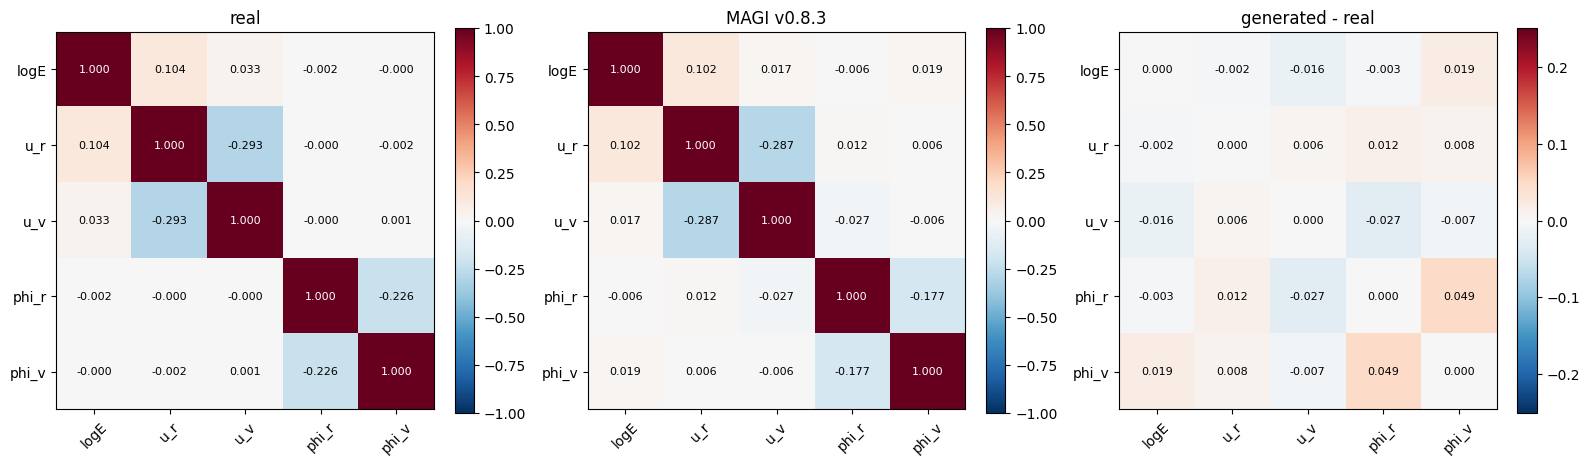

logE row (the energy<->geometry coupling):
  pair               real     MAGI     diff
  logE-u_r         0.1045   0.1022  -0.0023
  logE-u_v         0.0330   0.0171  -0.0159
  logE-phi_r      -0.0025  -0.0058  -0.0034
  logE-phi_v      -0.0005   0.0188  +0.0193

max |diff| over the whole matrix: 0.0486
max |diff| in the logE row      : 0.0193


In [9]:
corr_cols = ["logE", "u_r", "u_v", "phi_r", "phi_v"]

real_df = feature_pack["filtered_prep"]["features"].copy()
real_df["logE"] = np.log10(real_df["Energy"].to_numpy())

gen_df = pd.DataFrame({
    "logE": np.log10(E_gen),
    "u_r": gen_phys["u_r_gen"], "u_v": gen_phys["u_v_gen"],
    "phi_r": gen_phys["phi_r_gen"], "phi_v": gen_phys["phi_v_gen"],
})

Creal = real_df[corr_cols].corr(method="pearson").to_numpy()
Cgen = gen_df[corr_cols].corr(method="pearson").to_numpy()
D = Cgen - Creal

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, M, t, vm in ((axes[0], Creal, "real", 1), (axes[1], Cgen, "MAGI v0.8.3", 1),
                     (axes[2], D, "generated - real", 0.25)):
    im = ax.imshow(M, cmap="RdBu_r", vmin=-vm, vmax=vm)
    ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45)
    ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
    ax.set_title(t)
    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            ax.text(j, i, f"{M[i,j]:.3f}", ha="center", va="center", fontsize=8,
                    color="black" if abs(M[i, j]) < 0.6 * vm else "white")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.savefig("Plots/v0_8_3_correlation_matrices.png", dpi=150,
                                bbox_inches="tight"); plt.show()

print("logE row (the energy<->geometry coupling):")
print(f"  {'pair':14s} {'real':>8s} {'MAGI':>8s} {'diff':>8s}")
for j, c in enumerate(corr_cols):
    if c == "logE": continue
    print(f"  logE-{c:9s} {Creal[0,j]:8.4f} {Cgen[0,j]:8.4f} {D[0,j]:+8.4f}")
print(f"\nmax |diff| over the whole matrix: {np.abs(D).max():.4f}")
print(f"max |diff| in the logE row      : {np.abs(D[0]).max():.4f}")

## 8. THE CHECK — median energy vs impact parameter

The direct measure of the defect. v0.8.2 reference values to beat:

| cut | v0.8.2 ratio |
|---|---|
| all ingoing | 0.816 |
| b < 10 mm | 0.468 |
| b < 1 mm | **0.225** |

A fixed model stays near 1 at every cut.

energy vs impact parameter to the detector
  a healthy model keeps median_E_ratio ~1 at EVERY cut;
  a falling trend is the energy<->geometry coupling error (v0.8.2)
         cut    n_real     n_gen  medE_real   medE_gen   ratio
         all 2,931,454   380,980      22.79       19.7   0.865
      b<50mm   802,867   107,753      21.86      22.37   1.024
      b<20mm   128,388    18,080      23.15         22   0.950
      b<10mm    32,159     4,533      24.16      22.75   0.942
       b<5mm     8,021     1,098      21.98      15.62   0.711
       b<2mm     1,188       179       22.9      17.22   0.752
       b<1mm       302        46      23.69      3.357   0.142
  worst median_E_ratio = 0.142 at b<1mm   (v0.8.2 CR reference: 0.225 at b<1mm)


,cut_mm,n_real,n_gen,aimed_frac_ratio,median_E_ratio,v0_8_2_ratio,improvement
0,inf,2931454,380980,1.000000,0.864538,0.816,1.059483
1,50.0,802867,107753,1.032682,1.023560,0.708,1.445706
2,20.0,128388,18080,1.083565,0.950371,0.563,1.688049
3,10.0,32159,4533,1.084586,0.941878,0.468,2.012560
4,5.0,8021,1098,1.053306,0.710834,0.389,1.827336
5,2.0,1188,179,1.159358,0.752062,0.320,2.350195
6,1.0,302,46,1.172011,0.141686,0.225,0.629716


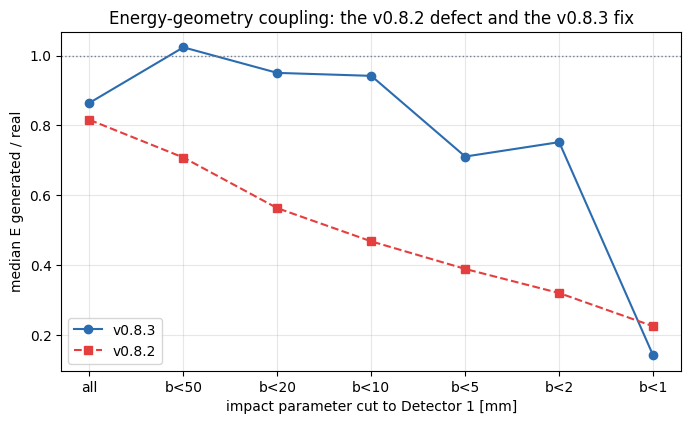

In [10]:
# Positions and unit directions of the REAL crossings, taken from the same
# filtered prep the model was trained on so the rows line up with E_real.
raw = feature_pack["filtered_prep"]["raw"]
nd = feature_pack["filtered_prep"]["normalized_direction"]
P_real = np.column_stack([raw["x"], raw["y"], raw["z"]])
U_real = np.column_stack([nd["vx"], nd["vy"], nd["vz"]])
E_real_full = real_df["Energy"].to_numpy()
assert P_real.shape[0] == real_df.shape[0] == E_real_full.shape[0]

P_gen = np.column_stack([gen_phys["x_gen"], gen_phys["y_gen"], gen_phys["z_gen"]])
U_gen = np.column_stack([gen_phys["vx_gen"], gen_phys["vy_gen"], gen_phys["vz_gen"]])

rows = magi.energy_vs_impact_parameter(
    P_real, U_real, E_real_full,
    P_gen, U_gen, E_gen,
    detector_centre=DET1)

tab = pd.DataFrame(rows)
V082 = {np.inf: 0.816, 50.0: 0.708, 20.0: 0.563, 10.0: 0.468,
        5.0: 0.389, 2.0: 0.320, 1.0: 0.225}
tab["v0_8_2_ratio"] = tab["cut_mm"].map(V082)
tab["improvement"] = tab["median_E_ratio"] / tab["v0_8_2_ratio"]
display(tab[["cut_mm", "n_real", "n_gen", "aimed_frac_ratio",
             "median_E_ratio", "v0_8_2_ratio", "improvement"]])

fig, ax = plt.subplots(figsize=(8, 4.4))
x = np.arange(len(tab))
ax.plot(x, tab["median_E_ratio"], "o-", color="#2b6cb0", label="v0.8.3")
ax.plot(x, tab["v0_8_2_ratio"], "s--", color="#e53e3e", label="v0.8.2")
ax.axhline(1.0, color="#718096", lw=1, ls=":")
ax.set_xticks(x)
ax.set_xticklabels(["all" if not np.isfinite(c) else f"b<{c:g}" for c in tab["cut_mm"]])
ax.set_xlabel("impact parameter cut to Detector 1 [mm]")
ax.set_ylabel("median E generated / real")
ax.set_title("Energy-geometry coupling: the v0.8.2 defect and the v0.8.3 fix")
ax.legend(); ax.grid(alpha=0.3)
plt.savefig("Plots/v0_8_3_energy_vs_b.png", dpi=150, bbox_inches="tight"); plt.show()

## 9. Marginals must not regress

In [11]:
E_real_full = real_df["Energy"].to_numpy()
print("energy spectrum by decade (v0.8.2 was 0.970-1.013 across these)")
print(f"{'decade [MeV]':>20s} {'real':>10s} {'MAGI':>10s} {'ratio':>8s}")
ed = [1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4, 1e6]
for lo, hi in zip(ed[:-1], ed[1:]):
    a = ((E_real_full >= lo) & (E_real_full < hi)).mean()
    b = ((E_gen >= lo) & (E_gen < hi)).mean()
    if a > 1e-4:
        print(f"{lo:9.3g} - {hi:<8.3g} {a:10.4%} {b:10.4%} {b/a:8.3f}")

print("\nline-integral recovery")
recovery = magi.compute_line_integral_recovery(
    E_real_full, E_gen, matched, energy_bins,
    energy_component_idx_gen=gen_phys["energy_component_idx_gen"],
    resolution_ev=X_IFU_RESOLUTION_EV)
for r in recovery:
    rec = "n/a" if r["recovery_ratio"] is None else f"{r['recovery_ratio']:.3f}"
    print(f"  {r['label']:22s} recovery {rec}")

energy spectrum by decade (v0.8.2 was 0.970-1.013 across these)
        decade [MeV]       real       MAGI    ratio
    0.001 - 0.01        0.8066%    0.5376%    0.666
     0.01 - 0.1         1.4140%    3.1106%    2.200
      0.1 - 1          33.3746%   32.4323%    0.972
        1 - 10         15.3232%   16.1906%    1.057
       10 - 100        10.5598%    9.1422%    0.866
      100 - 1e+03      19.9360%   20.9732%    1.052
    1e+03 - 1e+04      16.5798%   15.6397%    0.943
    1e+04 - 1e+06       2.0060%    1.9735%    0.984

line-integral recovery


  e+e- annihilation      recovery 1.613
  Al K-alpha1            recovery 0.896
  Cu K-alpha1            recovery 1.267
  Cu K-beta              recovery 0.760


## 10. Verdict

In [12]:
worst = tab.loc[tab["median_E_ratio"].idxmin()]
print("=" * 66)
print("MAGI v0.8.3 - energy x geometry coupling")
print("=" * 66)
print(f"  latent_dim                8 -> {LATENT_DIM}")
print(f"  energy_condition_geometry {model.energy_condition_geometry}")
print()
print(f"  worst median_E_ratio      {worst['median_E_ratio']:.3f} "
      f"at {'all' if not np.isfinite(worst['cut_mm']) else 'b<%g mm' % worst['cut_mm']}")
print(f"    v0.8.2 at the same cut  {worst['v0_8_2_ratio']:.3f}")
print(f"    improvement             {worst['median_E_ratio']/worst['v0_8_2_ratio']:.2f}x")
print()
print(f"  max |corr diff|, logE row {np.abs(D[0]).max():.4f}")
print(f"  max |corr diff|, all      {np.abs(D).max():.4f}")
print()
print("  PASS if median_E_ratio stays within ~0.85-1.15 at every cut AND the")
print("  energy decades stay within a few percent (no marginal regression).")

MAGI v0.8.3 - energy x geometry coupling
  latent_dim                8 -> 12
  energy_condition_geometry True

  worst median_E_ratio      0.142 at b<1 mm
    v0.8.2 at the same cut  0.225
    improvement             0.63x

  max |corr diff|, logE row 0.0193
  max |corr diff|, all      0.0486

  PASS if median_E_ratio stays within ~0.85-1.15 at every cut AND the
  energy decades stay within a few percent (no marginal regression).
